In [2]:
import os
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split

In [3]:
data_base_dir = "/data/CIFAR-10-C"

In [4]:
data_base_dir = "/data/CIFAR-10-C"

if not os.path.exists(data_base_dir):
    candidate = "./data/CIFAR-10-C"
    if os.path.exists(candidate):
        data_base_dir = candidate
    else:
        data_base_dir = "./playground/data/CIFAR-10-C"

print("Using data dir:", data_base_dir)

Using data dir: ./data/CIFAR-10-C


C:\Users\joobzm\Desktop\dacal-stream-learning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


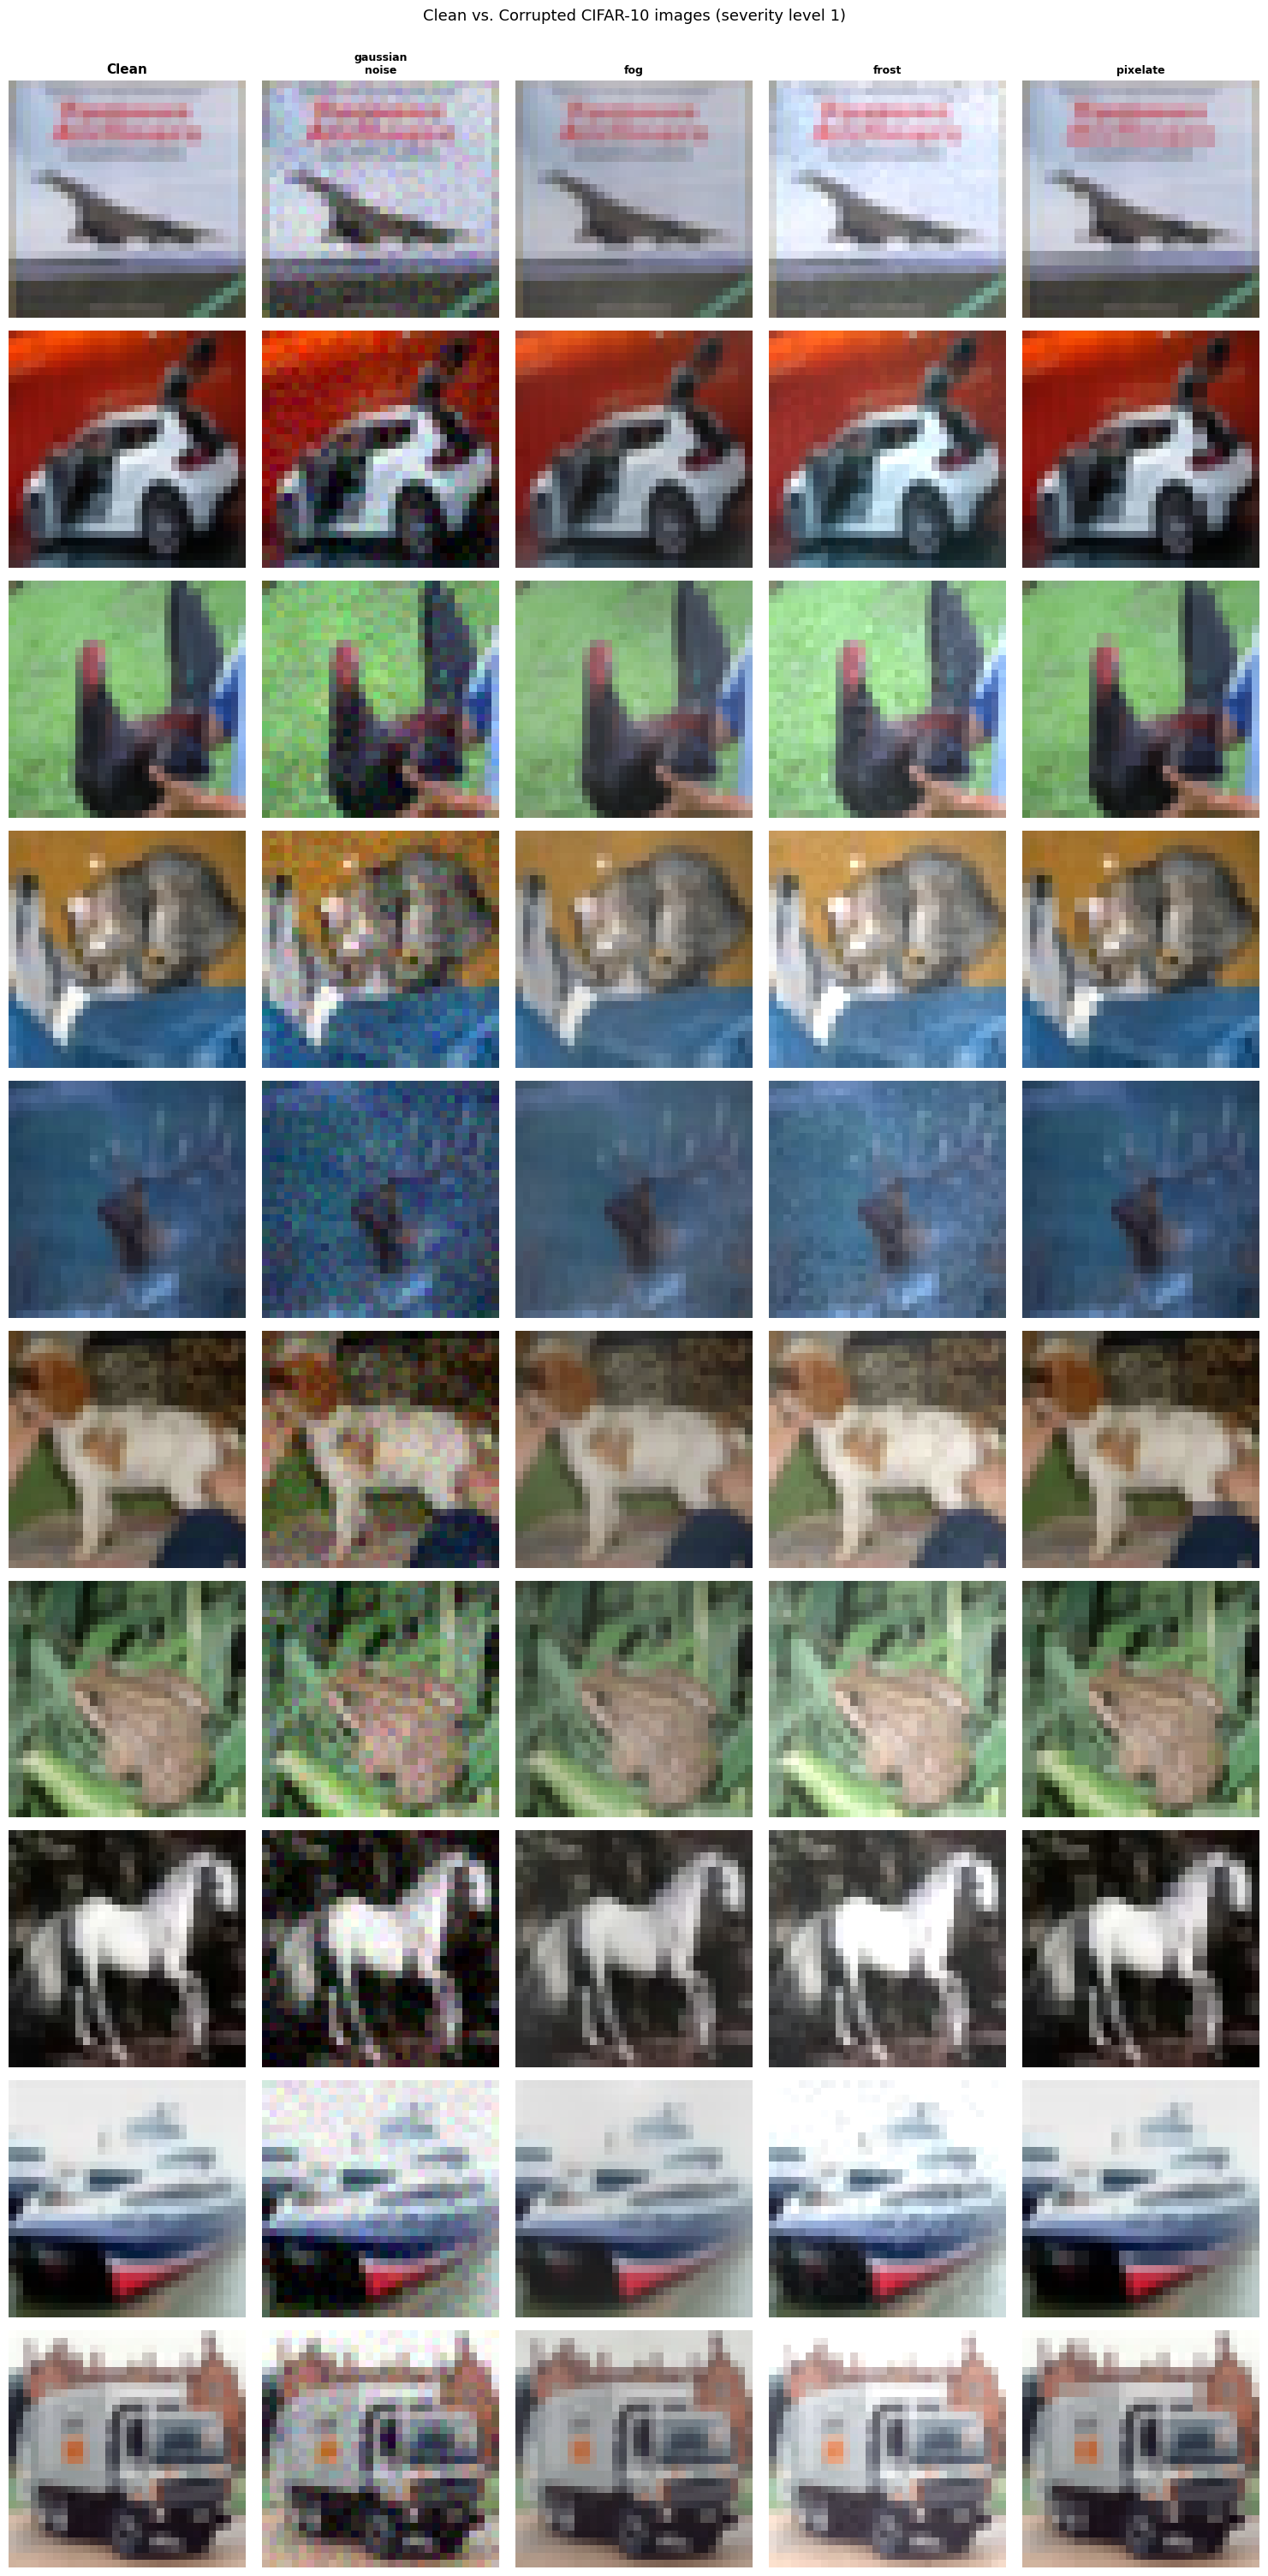

In [5]:

import matplotlib.pyplot as plt
import torchvision

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
corruption_types = [
    "brightness", "contrast", "defocus_blur", "elastic_transform", "fog",
    "frost", "gaussian_blur", "gaussian_noise", "glass_blur", "impulse_noise",
    "jpeg_compression", "motion_blur", "pixelate", "saturate", "shot_noise",
    "snow", "spatter", "speckle_noise", "zoom_blur",
]

# Load original clean CIFAR-10 test set (50 000 images, same order as CIFAR-10-C)
clean_ds = torchvision.datasets.CIFAR10(
    root="/tmp/cifar10", train=False, download=True
)
clean_images = np.array(clean_ds.data)  # (10000, 32, 32, 3)  uint8
clean_labels = np.array(clean_ds.targets)

# Pick one sample per class from the clean set
sample_indices = [np.where(clean_labels == c)[0][0] for c in range(10)]

# Choose which corruptions to display
selected_corruptions = ["gaussian_noise", "fog", "frost", "pixelate"]
severity_block = 0  # CIFAR-10-C stacks 5 severity levels × 10 000 images; block 0 = severity 1

fig, axes = plt.subplots(
    nrows=10,
    ncols=1 + len(selected_corruptions),
    figsize=(3 * (1 + len(selected_corruptions)), 3 * 10),
)

# Column headers
axes[0, 0].set_title("Clean", fontsize=11, fontweight="bold")
for col, name in enumerate(selected_corruptions, start=1):
    axes[0, col].set_title(name.replace("_", "\n"), fontsize=9, fontweight="bold")

for row, idx in enumerate(sample_indices):
    # --- clean image ---
    axes[row, 0].imshow(clean_images[idx])
    axes[row, 0].set_ylabel(classes[row], fontsize=9)
    axes[row, 0].axis("off")

    # --- corrupted images ---
    for col, corruption in enumerate(selected_corruptions, start=1):
        corrupt_path = os.path.join(data_base_dir, f"{corruption}.npy")
        corrupt_data = np.load(corrupt_path)  # (50000, 32, 32, 3)
        # CIFAR-10-C repeats labels 5 times (one per severity level):
        # find the same sample index within the first severity block (10 000 images)
        corrupt_img = corrupt_data[severity_block * 10000 + idx]  # uint8
        axes[row, col].imshow(corrupt_img)
        axes[row, col].axis("off")

plt.suptitle("Clean vs. Corrupted CIFAR-10 images (severity level 1)", fontsize=13, y=1.001)
plt.tight_layout()
plt.show()

In [4]:
x_path = os.path.join(data_base_dir, "gaussian_noise.npy")
y_path = os.path.join(data_base_dir, "labels.npy")

X = np.load(x_path)     # expected shape: (50000, 32, 32, 3)
y = np.load(y_path)     # expected shape: (50000,)

print("X shape:", X.shape, "dtype:", X.dtype)
print("y shape:", y.shape, "dtype:", y.dtype)
print("num classes:", len(np.unique(y)))

X shape: (50000, 32, 32, 3) dtype: uint8
y shape: (50000,) dtype: uint8
num classes: 10


In [5]:
X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0  # (N, 3, 32, 32)
y_tensor = torch.tensor(y, dtype=torch.long)

In [6]:
dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64)

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [9]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            total_loss += criterion(logits, y_batch).item() * len(y_batch)
            correct += (logits.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [10]:
for epoch in range(10):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)
    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.3f}")

Epoch  1 | Train Loss: 1.5190 Acc: 0.451 | Val Loss: 1.1923 Acc: 0.579
Epoch  2 | Train Loss: 1.0697 Acc: 0.621 | Val Loss: 0.9181 Acc: 0.673
Epoch  3 | Train Loss: 0.7611 Acc: 0.734 | Val Loss: 0.5959 Acc: 0.794
Epoch  4 | Train Loss: 0.5148 Acc: 0.822 | Val Loss: 0.4161 Acc: 0.859
Epoch  5 | Train Loss: 0.3514 Acc: 0.879 | Val Loss: 0.2330 Acc: 0.928
Epoch  6 | Train Loss: 0.2496 Acc: 0.914 | Val Loss: 0.1543 Acc: 0.956
Epoch  7 | Train Loss: 0.1803 Acc: 0.937 | Val Loss: 0.1090 Acc: 0.968
Epoch  8 | Train Loss: 0.1474 Acc: 0.950 | Val Loss: 0.0873 Acc: 0.974
Epoch  9 | Train Loss: 0.1285 Acc: 0.956 | Val Loss: 0.0730 Acc: 0.979
Epoch 10 | Train Loss: 0.1112 Acc: 0.961 | Val Loss: 0.0734 Acc: 0.977


In [11]:
model.eval()
test_loader = DataLoader(val_ds, batch_size=64)

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y_batch)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

accuracy = (all_preds == all_labels).float().mean().item()
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Per-class accuracy
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
for i, cls in enumerate(classes):
    mask = all_labels == i
    cls_acc = (all_preds[mask] == all_labels[mask]).float().mean().item()
    print(f"  {cls:<12}: {cls_acc:.3f}")

Test Accuracy: 0.9769 (97.69%)
  airplane    : 0.977
  automobile  : 0.994
  bird        : 0.956
  cat         : 0.950
  deer        : 0.981
  dog         : 0.939
  frog        : 0.994
  horse       : 0.995
  ship        : 0.996
  truck       : 0.990
